# Seaborn Visualization Practice

This notebook uses a small dataset about Indian students. The syntax is kept simple for a beginner-level class.

In [3]:
!pip install --upgrade pip

     |████████████████████████████████| 1.8 MB 954 kB/s eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 21.2.4
    Uninstalling pip-21.2.4:
      Successfully uninstalled pip-21.2.4


In [5]:
!pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 5.3 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 5.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 6.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [seaborn]m7/9 [matplotlib]esources]


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
data = pd.read_csv('visualization_data.csv')
data.head()

,Student_ID,Name,City,Gender,Course,Month,Study_Hours,Attendance_Percentage,Assignment_Score,Exam_Score,Sleep_Hours,Screen_Time_Hours,Monthly_Expense_Rupees,Transport_Mode
0,1,Aarav,Delhi,Male,BBA,January,3.0,78,68,70,7.0,4.5,8500,Metro
1,1,Aarav,Delhi,Male,BBA,February,3.5,80,72,74,7.0,4.0,8700,Metro
2,1,Aarav,Delhi,Male,BBA,March,4.0,84,76,78,6.8,3.8,8900,Metro
3,1,Aarav,Delhi,Male,BBA,April,4.5,86,80,82,6.7,3.5,9100,Metro
4,2,Ananya,Mumbai,Female,BCom,January,4.0,85,75,78,7.5,3.5,12000,Local Train


In [9]:
data.shape

(48, 14)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              48 non-null     int64  
 1   Name                    48 non-null     object 
 2   City                    48 non-null     object 
 3   Gender                  48 non-null     object 
 4   Course                  48 non-null     object 
 5   Month                   48 non-null     object 
 6   Study_Hours             48 non-null     float64
 7   Attendance_Percentage   48 non-null     int64  
 8   Assignment_Score        48 non-null     int64  
 9   Exam_Score              48 non-null     int64  
 10  Sleep_Hours             48 non-null     float64
 11  Screen_Time_Hours       48 non-null     float64
 12  Monthly_Expense_Rupees  48 non-null     int64  
 13  Transport_Mode          48 non-null     object 
dtypes: float64(3), int64(5), object(6)
memory us

## 1. Count Plot

A count plot is used to count categories.

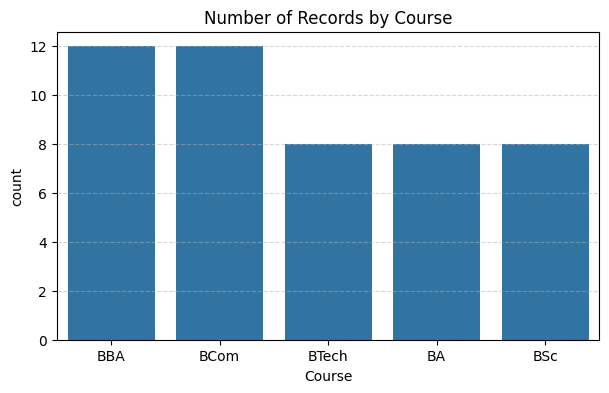

In [53]:
plt.figure(figsize=(7, 4))
sns.countplot(data=data, x='Course')
plt.title('Number of Records by Course')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 2. Bar Plot

A bar plot can compare average values for different groups.

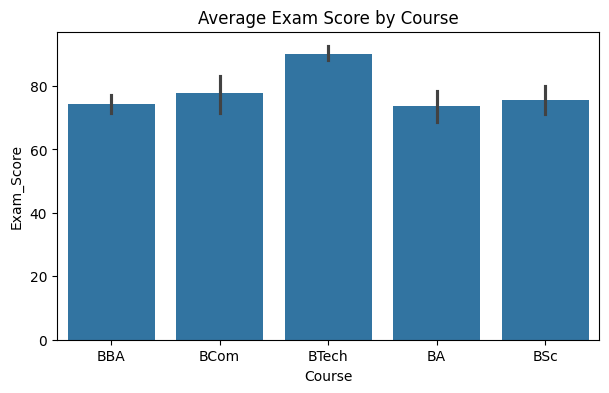

In [16]:
plt.figure(figsize=(7, 4))
sns.barplot(data=data, x='Course', y='Exam_Score')
plt.title('Average Exam Score by Course')
plt.show()

## 3. Line Plot

A line plot is useful for showing change over time.

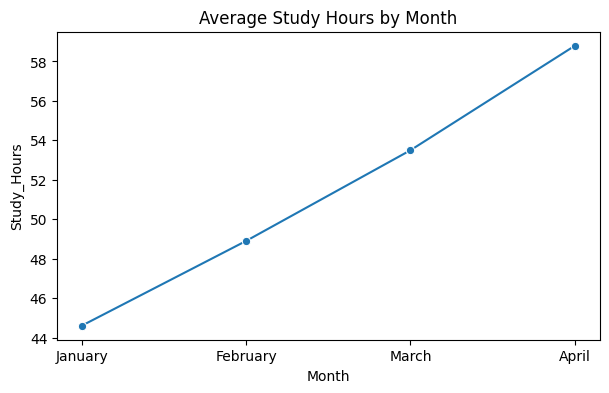

In [49]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=data, x='Month', y='Study_Hours', estimator=np.sum,
             marker='o',err_style=None)
plt.title('Average Study Hours by Month')
plt.show()

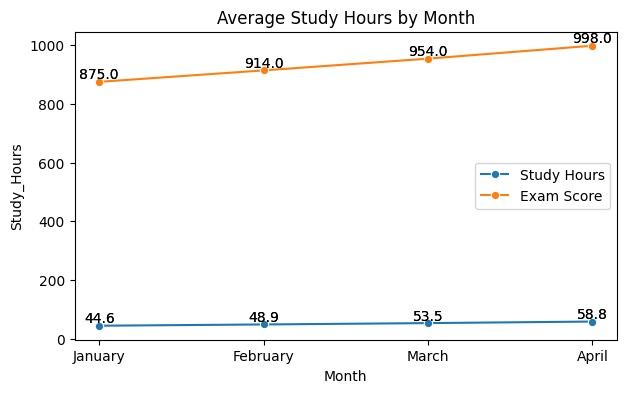

In [42]:
plt.figure(figsize=(7, 4))
ax1=sns.lineplot(data=data, x='Month', y='Study_Hours', estimator=np.sum,
             marker='o',err_style=None, label='Study Hours')
ax2=sns.lineplot(data=data, x='Month', y='Exam_Score', estimator=np.sum,
             marker='o',err_style=None,label='Exam Score')
plt.title('Average Study Hours by Month')
for line in ax1.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x, y, f"{y:.1f}", ha="center", va="bottom")
for line in ax2.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x, y, f"{y:.1f}", ha="center", va="bottom")
plt.show()

## 4. Histogram

A histogram shows the spread of one numeric column.

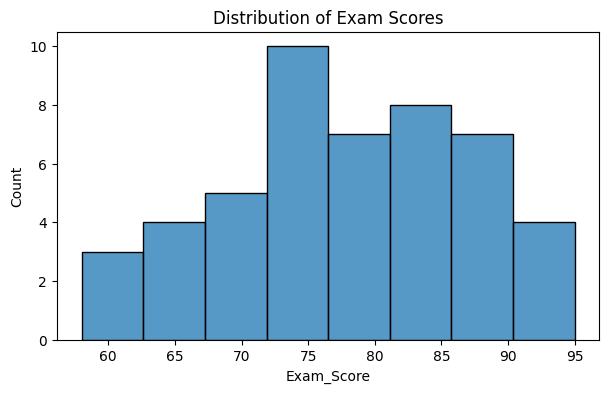

In [45]:
plt.figure(figsize=(7, 4))
ax=sns.histplot(data=data, x='Exam_Score', bins=8)
plt.title('Distribution of Exam Scores')
plt.show()

## 5. Box Plot

A box plot helps us compare the spread of values.

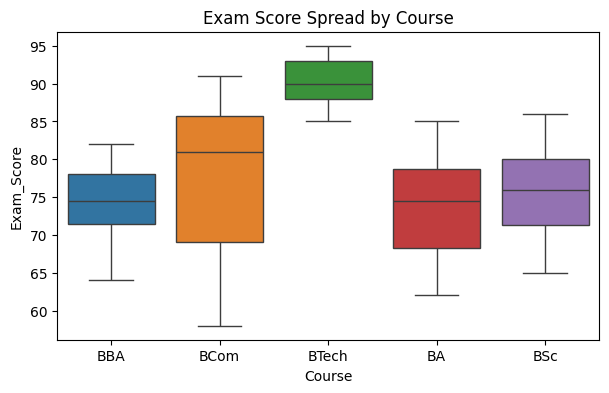

In [56]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=data, x='Course', y='Exam_Score',hue='Course')
plt.title('Exam Score Spread by Course')
plt.show()

## 6. Scatter Plot

A scatter plot shows the relationship between two numeric columns.

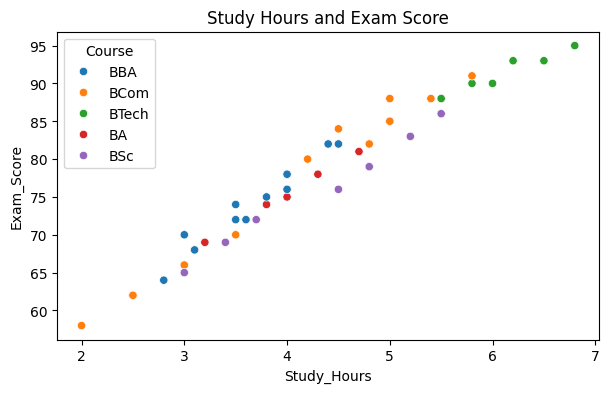

In [47]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data, x='Study_Hours', y='Exam_Score', hue='Course')
plt.title('Study Hours and Exam Score')
plt.show()

## 7. Violin Plot

A violin plot shows distribution and comparison together.

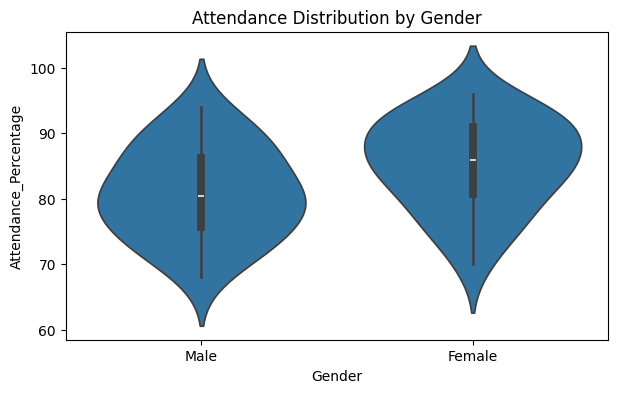

In [55]:
plt.figure(figsize=(7, 4))
sns.violinplot(data=data, x='Gender', y='Attendance_Percentage')
plt.title('Attendance Distribution by Gender')
plt.show()

## 8. Heatmap

A heatmap is often used to show correlation between numeric columns.

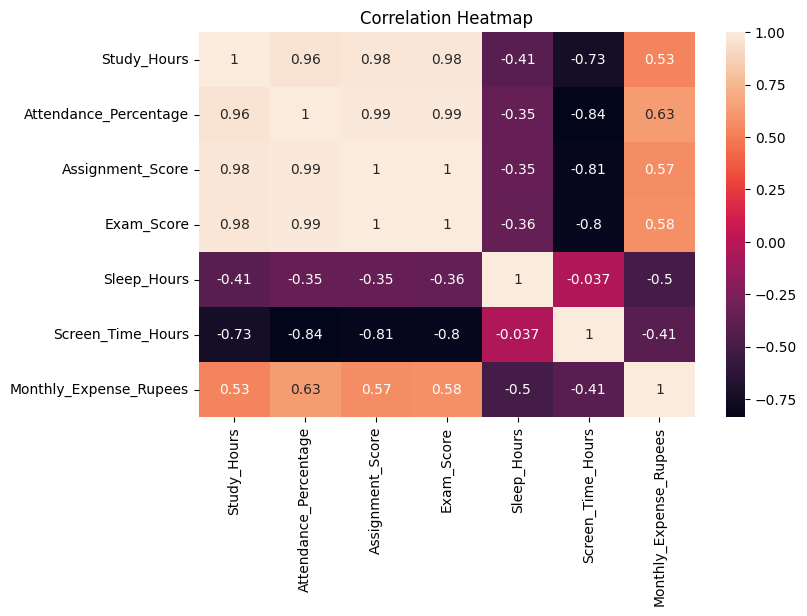

In [34]:
numeric_data = data[['Study_Hours', 'Attendance_Percentage', 'Assignment_Score', 'Exam_Score', 'Sleep_Hours', 'Screen_Time_Hours', 'Monthly_Expense_Rupees']]

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_data.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

## 9. Pair Plot

A pair plot shows many numeric relationships at once.

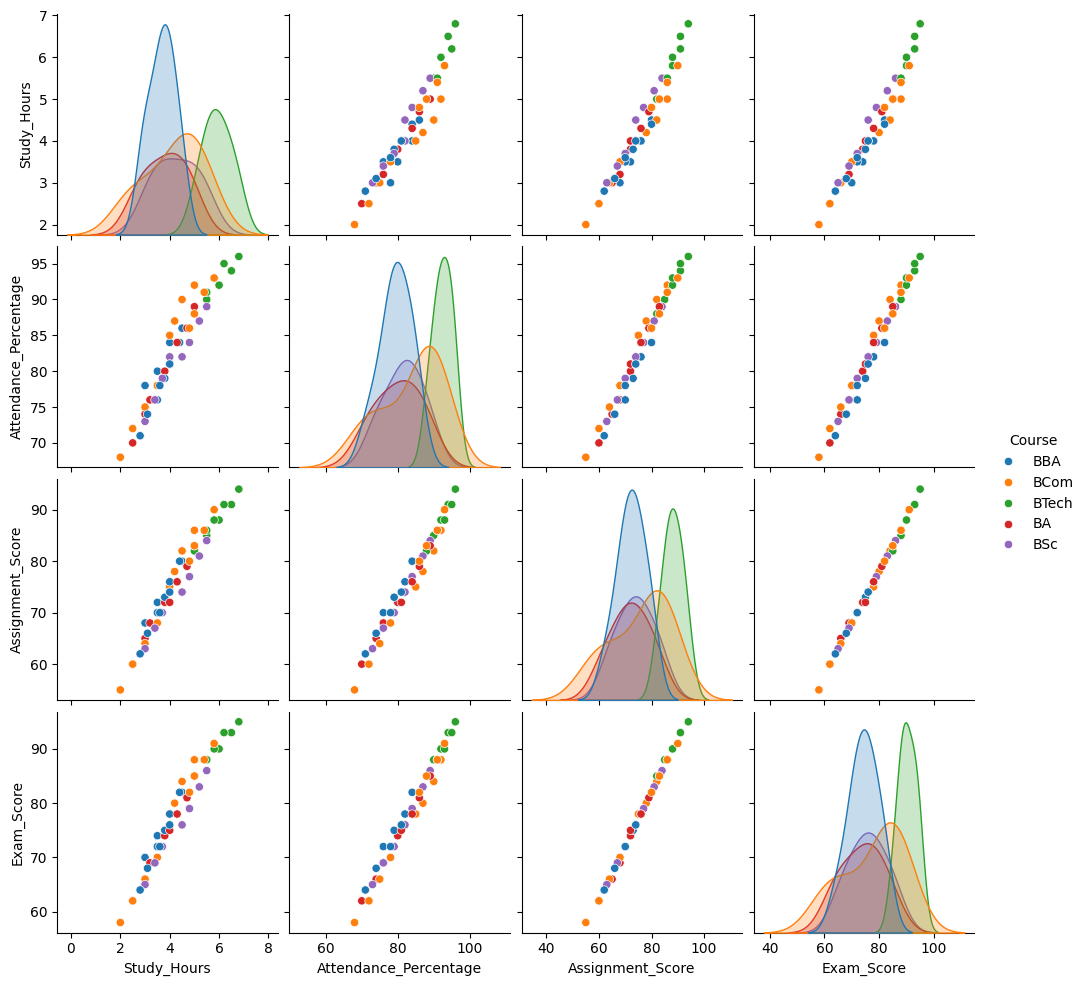

In [35]:
small_data = data[['Study_Hours', 'Attendance_Percentage', 'Assignment_Score', 'Exam_Score', 'Course']]
sns.pairplot(data=small_data, hue='Course')
plt.show()